# Mental Rotation 2D Environment Demo

This notebook demonstrates the Mental Rotation 2D environment where you rotate an image to match the original.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [3]:
env = gym.make("mental_rotation_2d/easy", seed=42)
print(f"Tolerance: {env.unwrapped.tolerance}°")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")
print(f"Rotation range: -180° to 180°")

Tolerance: 10.0°
Action Space: FuncConditional(['rotate', 'stop'])
Available actions: ['rotate', 'stop']
Rotation range: -180° to 180°


## 2. Reset and View Initial State

Observation shape: (128, 256, 3)
Secret angle (ground truth): 71.00°
Current agent angle: 0.00°


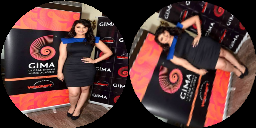


Task: Rotate the right image to match the left

Task Prompt:
You are solving a mental rotation task. Two panels appear side by side:
- Left: the original circular image.
- Right: the image has been rotated by a secret angle.
Your job is to undo that rotation and align the right image back to match the left.

Available actions:
1. 'rotate': Rotate the right image by an integer angle. Format: `('rotate', angle)` where angle is an integer between -180 and 180 degrees (positive is clockwise, negative is counterclockwise).
2. 'stop': Submit your final adjustment. Format: `('stop', 'stop')`

Success: You succeed if your final adjustment undoes the secret rotation within ±10.0°.

Please respond with exactly one action and its arguments in the specified format. For example:
- To rotate clockwise: `('rotate', 45)`
- To rotate counterclockwise: `('rotate', -30)`
- To submit: `('stop', 'stop')`


In [5]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Secret angle (ground truth): {env.unwrapped.secret_angle:.2f}°")
print(f"Current agent angle: {env.unwrapped.agent_angle:.2f}°")

display(Image.fromarray(obs))
print(f"\nTask: Rotate the right image to match the left")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('rotate', 45)
Agent angle: 90.00°
Feedback: Action executed successfully.


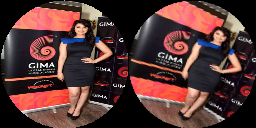

In [7]:
# Rotate clockwise
action = "('rotate', 45)"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Agent angle: {env.unwrapped.agent_angle:.2f}°")
print(f"Feedback: {info['env_feedback']}")
display(Image.fromarray(obs))

Action: ('rotate', -30)
Agent angle: 30.00°


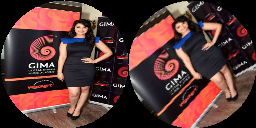

In [9]:
# Rotate counter-clockwise
action = "('rotate', -30)"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Agent angle: {env.unwrapped.agent_angle:.2f}°")
display(Image.fromarray(obs))

## 4. Test Solver

Secret rotation: 7.00°
Initial agent angle: 0.00°


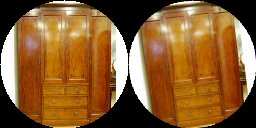


Solver generated 1 actions: ["('stop', 'stop')"]

Step 1: ('stop', 'stop')
Agent angle: 0.00°
Error: N/A°


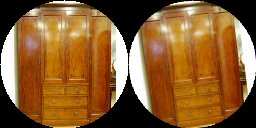


✓ Rotation complete! Reward: 1.0


In [11]:
env = gym.make("mental_rotation_2d/easy", seed=100)
obs, info = env.reset()
print(f"Secret rotation: {env.unwrapped.secret_angle:.2f}°")
print(f"Initial agent angle: {env.unwrapped.agent_angle:.2f}°")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions: {actions}")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: {action}")
    print(f"Agent angle: {env.unwrapped.agent_angle:.2f}°")
    print(f"Error: {info.get('angle_error', 'N/A')}°")
    display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Rotation complete! Reward: {reward}")
        break

env.close()

## 5. Test Solver with Multiple Steps

In [13]:
env = gym.make("mental_rotation_2d/easy", seed=200)
obs, info = env.reset()
print(f"Secret rotation: {env.unwrapped.secret_angle:.2f}°")

# Get solver actions with minimum 5 rotation steps
actions = env.solve(num_steps=5)
print(f"\nSolver generated {len(actions)} actions (requested 5 steps)")
print(f"Actions: {actions}")

for action in actions:
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        print(f"\nFinal reward: {reward}")
        print(f"Final angle error: {info.get('angle_error', 'N/A')}°")
        break

env.close()

Secret rotation: 39.00°

Solver generated 6 actions (requested 5 steps)
Actions: ["('rotate', 2)", "('rotate', 1)", "('rotate', 10)", "('rotate', 11)", "('rotate', 15)", "('stop', 'stop')"]

Final reward: 1.0
Final angle error: N/A°


## 6. Test Hard Difficulty (Stricter Tolerance)

Hard difficulty - tolerance: 5.0° (vs easy: 10°)
Secret rotation: 188.00°


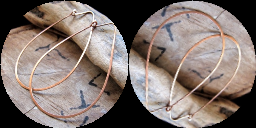


Solution: ["('rotate', -166)", "('rotate', -6)", "('stop', 'stop')"]
Reward: 1.0


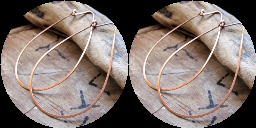

In [15]:
env_hard = gym.make("mental_rotation_2d/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - tolerance: {env_hard.unwrapped.tolerance}° (vs easy: 10°)")
print(f"Secret rotation: {env_hard.unwrapped.secret_angle:.2f}°")
display(Image.fromarray(obs))

# Solve it
actions = env_hard.solve()
print(f"\nSolution: {actions}")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Reward: {reward}")
        display(Image.fromarray(obs))
        break

env_hard.close()